In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import warnings
warnings.filterwarnings("ignore")
import random
import yaml
import numpy as np
import matplotlib.pyplot as plt
from argparse import Namespace
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from momentfm.utils.forecasting_metrics import mse, mae
from momentfm import MOMENTPipeline
from momentfm.utils.masking import Masking
from data.interfaces.TelecomTS import TelecomTS

In [2]:
def control_randomness(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
with open("config.yaml", "r") as f:
        cfg = yaml.safe_load(f)

dataset_cfg = cfg.pop("dataset") 
args = Namespace(**cfg)     

In [4]:
control_randomness(args.seed)

In [5]:
DATASET_REGISTRY = {
    "TelecomTS": TelecomTS
}

In [6]:
ds_class_name = dataset_cfg["class"]

if ds_class_name not in DATASET_REGISTRY:
    raise ValueError(f"Unknown dataset class: {ds_class_name}")
    
DatasetClass = DATASET_REGISTRY[ds_class_name]

In [7]:
device = f"cuda:{args.device}" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [8]:
test_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="test", conf=dataset_cfg)
test_dataloader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, drop_last=False)

In [9]:
sample_x, _ = test_dataset[0]
C, T = sample_x.shape

print(f"===== {dataset_cfg['class']} Dataset Summary =====")
print(f"============ Task: {dataset_cfg['task']['name']} ============")
print(f"Test windows     : {len(test_dataset)}")
print(f"Channels         : {C}")
print(f"Sequence length  : {T}")

===== TelecomTS Dataset Summary =====
============ Task: imputation ============
Test windows     : 582
Channels         : 8
Sequence length  : 512


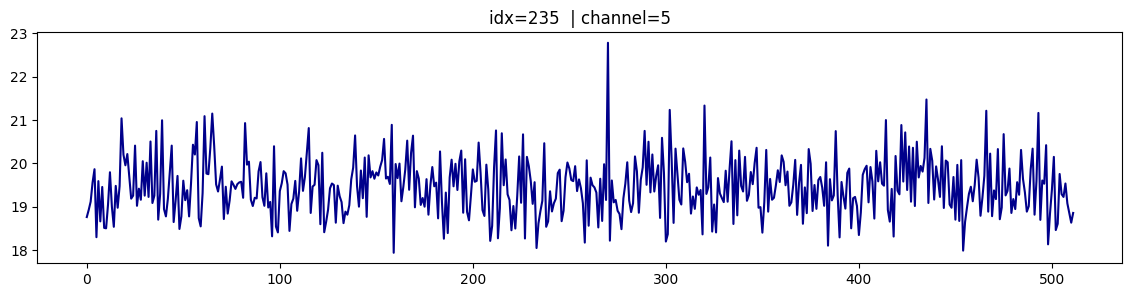

In [10]:
n_channels = test_dataset[0][0].shape[0]
idx = np.random.randint(0, len(test_dataset))
channel_idx = np.random.randint(0, n_channels)
plt.figure(figsize=(14, 3))
plt.plot(test_dataset[idx][0][channel_idx, :].squeeze(), c='darkblue')
plt.title(f'idx={idx}  | channel={channel_idx}')
plt.show()

In [11]:
VARIANT_TO_MODEL = {
    "small": "AutonLab/MOMENT-1-small",
    "base":  "AutonLab/MOMENT-1-base",
    "large": "AutonLab/MOMENT-1-large",
}

VARIANT_TO_CHECKPOINT = {
    "small": "../data/checkpoints/small/TimeRAN_small.pth",
    "base":  "../data/checkpoints/base/TimeRAN_base.pth",
    "large": "../data/checkpoints/large/TimeRAN_large.pth",
}

variant = cfg["variant"].lower()
BACKEND = cfg["backend"]

if variant not in VARIANT_TO_MODEL:
    raise ValueError(f"Unknown variant '{cfg['variant']}'. Choose from {list(VARIANT_TO_MODEL.keys())}")

if BACKEND not in ["TimeRAN", "MOMENT"]:
    raise ValueError("backend must be either 'TimeRAN' or 'MOMENT'")

MODEL_NAME = VARIANT_TO_MODEL[variant]

model = MOMENTPipeline.from_pretrained(
    MODEL_NAME,
    model_kwargs={"task_name": "reconstruction"}
)
model.init()

if BACKEND == "TimeRAN":
    CHECKPOINT_PATH = VARIANT_TO_CHECKPOINT[variant]

    print(f"Loading backbone: {MODEL_NAME}")
    print(f"Loading local checkpoint: {CHECKPOINT_PATH}")

    state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)

    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

elif BACKEND == "MOMENT":
    print(f"Using Hugging Face pretrained MOMENT weights only: {MODEL_NAME}")

else:
    raise ValueError(f"Unknown backend: {BACKEND}")

model = model.to(device)


Loading backbone: AutonLab/MOMENT-1-base
Loading local checkpoint: ../data/checkpoints/base/TimeRAN_base.pth


In [ ]:
mask_generator = Masking(mask_ratio=dataset_cfg["mask_ratio"])
model.eval()
trues, preds, masks = [], [], []

with torch.no_grad():
    for batch_x, batch_masks in tqdm(test_dataloader, total=len(test_dataloader)):
        trues.append(batch_x.numpy())
        
        batch_x = batch_x.to(device).float()
        n_channels = batch_x.shape[1]
        
        batch_x = batch_x.reshape((-1, 1, dataset_cfg["seq_len"])) 
        
        batch_masks = batch_masks.to(device).long()
        batch_masks = batch_masks.repeat_interleave(n_channels, axis=0)
        
        mask = mask_generator.generate_mask(x=batch_x, input_mask=batch_masks).to(device).long()

        output = model(x_enc=batch_x, input_mask=batch_masks, mask=mask) 
        
        reconstruction = output.reconstruction.detach().cpu().numpy()
        mask = mask.detach().squeeze().cpu().numpy()
        
        reconstruction = reconstruction.reshape((-1, n_channels, dataset_cfg["seq_len"])) 
        mask = mask.reshape((-1, n_channels, dataset_cfg["seq_len"]))
                
        preds.append(reconstruction)
        masks.append(mask)

preds = np.concatenate(preds)
trues = np.concatenate(trues)
masks = np.concatenate(masks)

print(f"Shapes: preds={preds.shape} | trues={trues.shape} | masks={masks.shape}")


100%|██████████| 19/19 [00:04<00:00,  4.05it/s]

Shapes: preds=(582, 8, 512) | trues=(582, 8, 512) | masks=(582, 8, 512)


In [13]:
print(f"MSE={mse(y=trues[masks==0], y_hat=preds[masks==0], reduction='mean'):.4f} | "f"MAE={mae(y=trues[masks==0], y_hat=preds[masks==0], reduction='mean'):.4f}")


MSE=9.1092 | MAE=0.8455


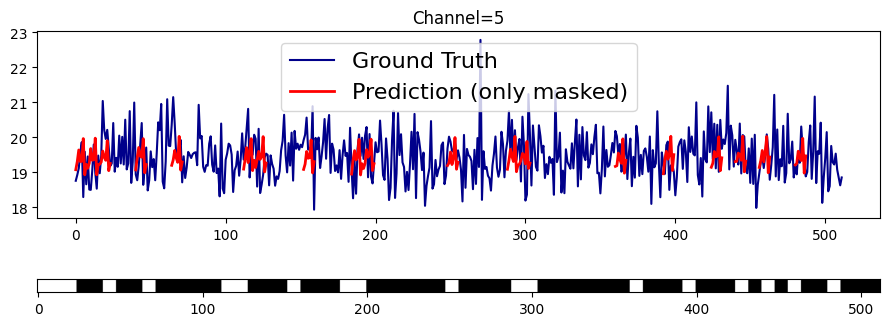

In [14]:
ts_true = trues[idx, channel_idx, :].squeeze()   
ts_pred = preds[idx, channel_idx, :].squeeze()   
ts_mask = masks[idx, channel_idx, :].squeeze()   
fig, axs = plt.subplots(2, 1, figsize=(9, 4))

axs[0].set_title(f"Channel={channel_idx}")
axs[0].plot(ts_true, label='Ground Truth', c='darkblue')

viz_pred = np.full_like(ts_true, np.nan)
viz_pred[ts_mask == 0] = ts_pred[ts_mask == 0]

axs[0].plot(viz_pred, label='Prediction (only masked)', c='red', linewidth=2)
axs[0].legend(fontsize=16)
axs[1].imshow(np.tile(ts_mask[np.newaxis, :], reps=(8, 1)), cmap='binary')
axs[1].set_yticks([])

plt.tight_layout()
plt.show()